In [5]:
# 기본
import pandas as pd
import numpy as np

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

import os
import gc


import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
import pipe

In [11]:
#상관계수 높은 13개 칼럼
df=pd.read_csv("data/abcorr.csv",encoding='utf-8-sig',index_col=0)
df['ab'][4:20].index.values
df_cd=pipe.call_df(0,*df['ab'][:13].values)

In [13]:
#vif계수를 사용한 5개 칼럼
col=['카드이용한도금액_B1M'
,'카드이용한도금액_B2M'     
,'카드이용한도금액'       
,'CA한도금액'          
,'이용건수_선결제_R6M'    
,'선결제건수_R6M'        
,'상환개월수_결제일_R6M'   
,'이용금액_선결제_R6M'     
,'선입금원금_B2M'       
,'이용횟수_선결제_R6M'     
,'선입금원금_B0M'    ]

df_cd=pipe.call_df(0,*col)

In [187]:
df_cd['ab']= (df_cd['Segment']== 'A') | (df_cd['Segment']== 'B')

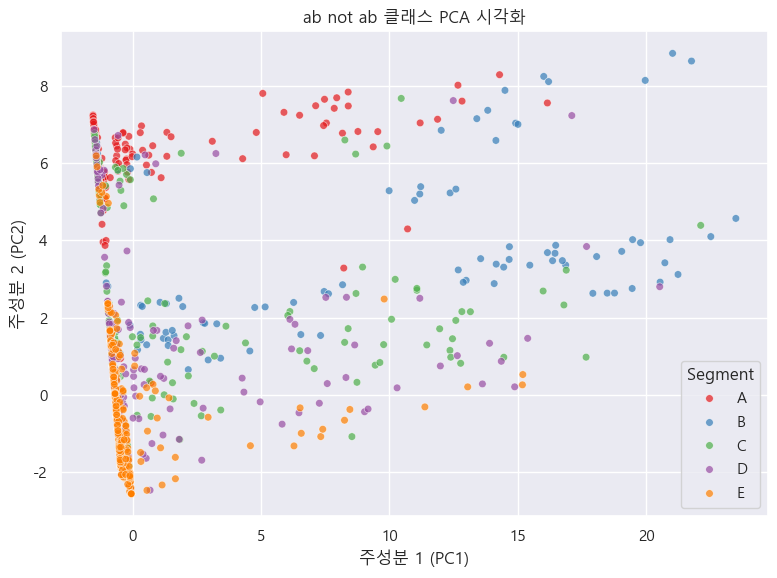

In [25]:
from sklearn.decomposition import PCA


df_cd['ab']= (df_cd['Segment']== 'A') | (df_cd['Segment']== 'B')


x_cd=df_cd.copy()
y_cd=x_cd['ab']
x_cd=x_cd.drop(['Segment','ab'],axis=1)
le = LabelEncoder()
y_cd=le.fit_transform(y_cd)


# 스케일링
scaler = StandardScaler()
x_cd_scaled = scaler.fit_transform(x_cd)

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(x_cd_scaled)

# 시각화용 DataFrame 생성
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2','PC3'])
df_pca['ab'] = le.inverse_transform(y_cd)
df_pca['Segment']=df_cd['Segment']

samples_per_category=300
stratified_sample_df = pd.DataFrame()
for category, group in df_pca.groupby('Segment'):
    n_to_sample = min(len(group), samples_per_category)
    sampled_group = group.sample(n=n_to_sample, random_state=42, replace=False)
    stratified_sample_df = pd.concat([stratified_sample_df, sampled_group])








# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=stratified_sample_df, x='PC1', y='PC2', hue='Segment', palette='Set1', s=30, alpha=0.7)
plt.title("ab not ab 클래스 PCA 시각화")
plt.xlabel("주성분 1 (PC1)")
plt.ylabel("주성분 2 (PC2)")
plt.legend(title='Segment')
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# 이미 학습된 PCA 객체 기준
# pca는 앞서 사용한 PCA(n_components=2) 객체라고 가정
# X_ab_scaled는 PCA에 사용된 스케일링된 입력 데이터
# X_ab.columns는 원래 피처 이름

# 주성분 구성 DataFrame 만들기
components_df = pd.DataFrame(
    data=pca.components_,
    columns=x_cd.columns,
    index=['PC1', 'PC2','PC3']
).T  # 전치해서 피처별로 보기 쉽게

# 절댓값 기준 기여도 순 정렬해서 상위 피처 보기
top_pc1 = components_df['PC1'].abs().sort_values(ascending=False).head(10)
top_pc2 = components_df['PC2'].abs().sort_values(ascending=False).head(10)

print("[PC1에 가장 큰 영향을 미친 피처 Top 10]")
print(top_pc1)

print("\n[PC2에 가장 큰 영향을 미친 피처 Top 10]")
print(top_pc2)

[PC1에 가장 큰 영향을 미친 피처 Top 10]
이용횟수_선결제_R6M     0.410564
이용금액_선결제_R6M     0.409043
선결제건수_R6M        0.405451
선입금원금_B0M        0.399291
선입금원금_B2M        0.399257
이용건수_선결제_R6M     0.381578
상환개월수_결제일_R6M    0.146889
CA한도금액           0.060982
카드이용한도금액_B2M     0.057980
카드이용한도금액_B1M     0.057934
Name: PC1, dtype: float64

[PC2에 가장 큰 영향을 미친 피처 Top 10]
카드이용한도금액_B1M     0.495169
카드이용한도금액         0.494028
카드이용한도금액_B2M     0.492746
CA한도금액           0.478544
상환개월수_결제일_R6M    0.140928
이용금액_선결제_R6M     0.061655
선입금원금_B2M        0.057284
선입금원금_B0M        0.056987
이용횟수_선결제_R6M     0.055877
이용건수_선결제_R6M     0.055626
Name: PC2, dtype: float64


In [23]:
df_pca.to_csv('data/abnotab_pca3.csv',encoding='utf-8-sig',index=False)

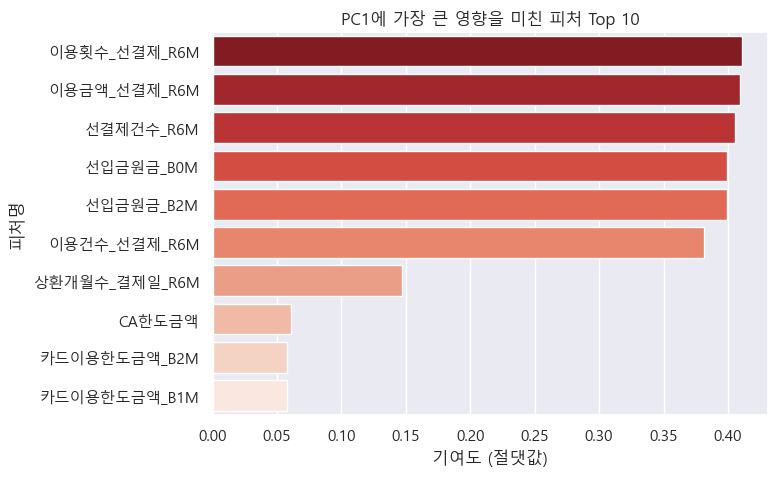

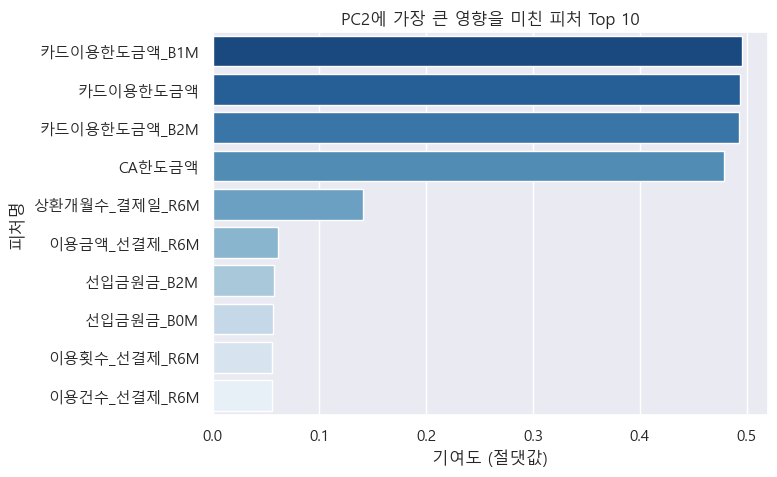

In [145]:
# 기여도 계산 (절댓값 기준 상위 10개 피처)
top_pc1 = components_df['PC1'].abs().sort_values(ascending=False).head(10)
top_pc2 = components_df['PC2'].abs().sort_values(ascending=False).head(10)

# PC1 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=top_pc1.values, y=top_pc1.index, palette='Reds_r')
plt.title("PC1에 가장 큰 영향을 미친 피처 Top 10")
plt.xlabel("기여도 (절댓값)")
plt.ylabel("피처명")
plt.tight_layout()
plt.show()

# PC2 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=top_pc2.values, y=top_pc2.index, palette='Blues_r')
plt.title("PC2에 가장 큰 영향을 미친 피처 Top 10")
plt.xlabel("기여도 (절댓값)")
plt.ylabel("피처명")
plt.tight_layout()
plt.show()

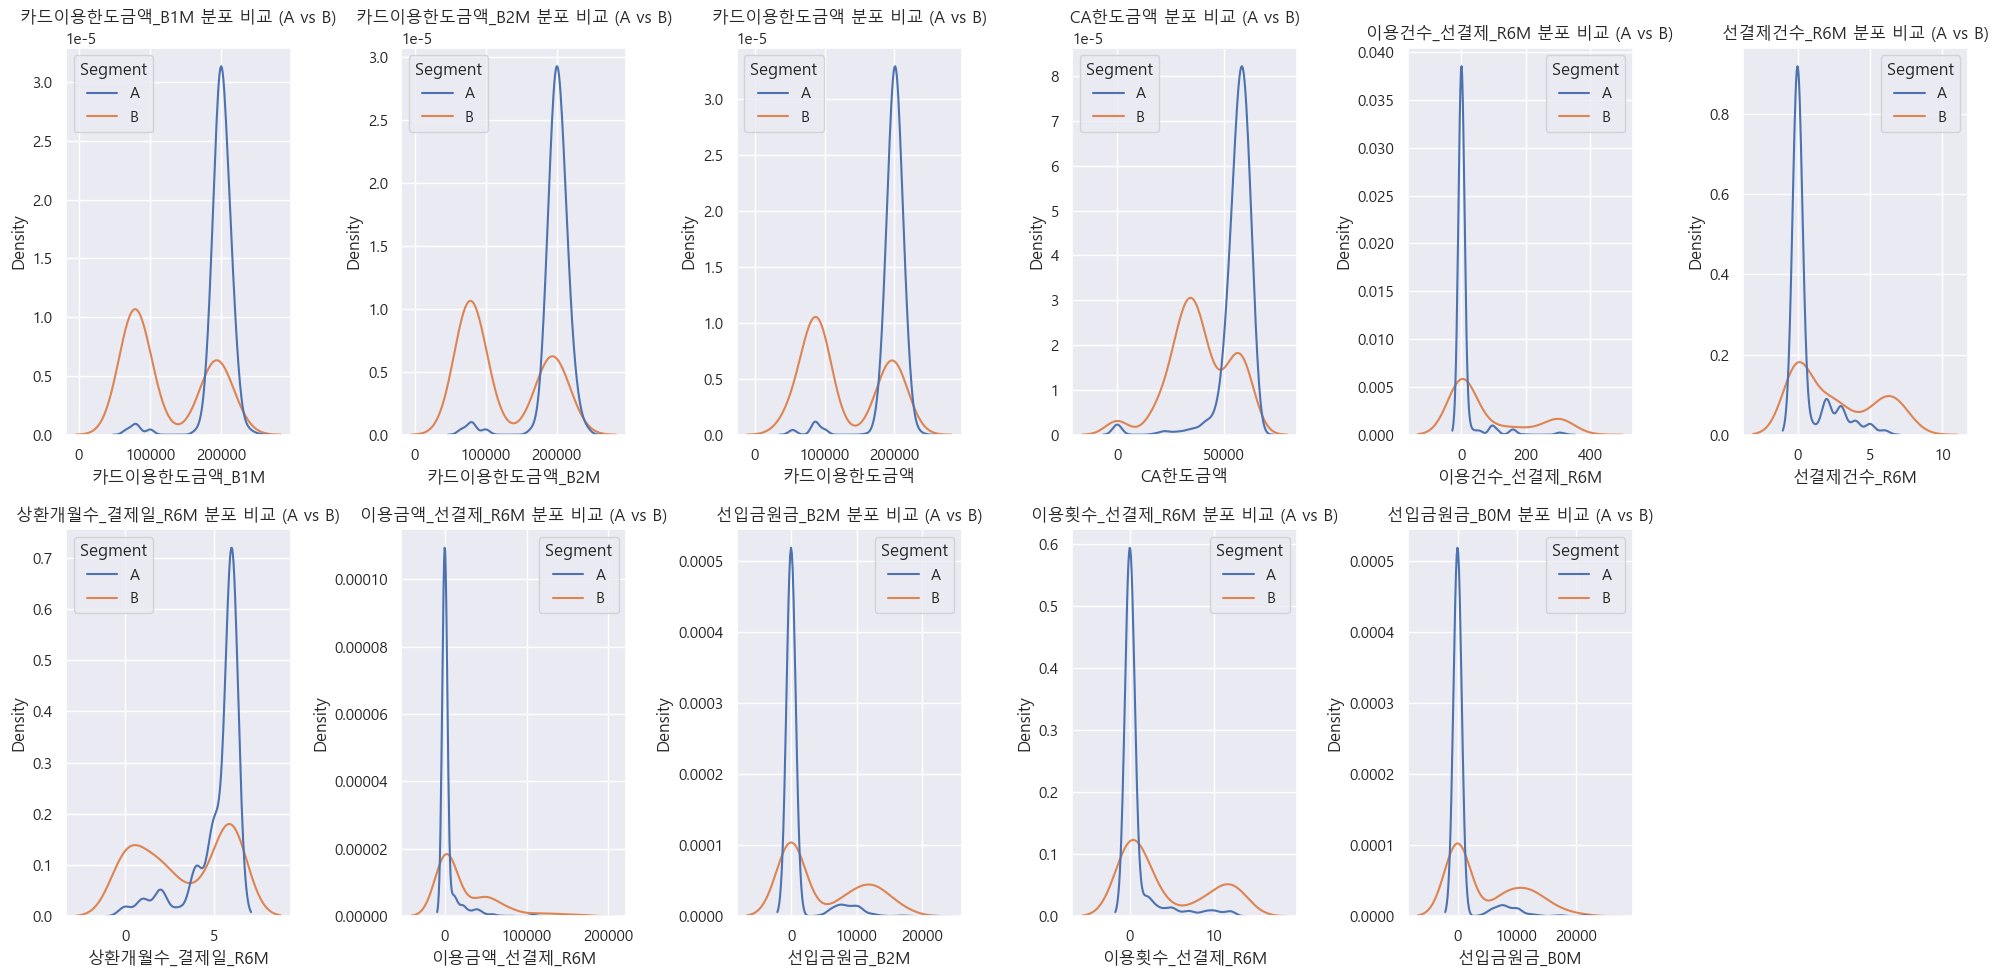

In [121]:
x_cd=df_cd[df_cd['ab']==True]
features = ['카드이용한도금액_B1M'
,'카드이용한도금액_B2M'     
,'카드이용한도금액'       
,'CA한도금액'          
,'이용건수_선결제_R6M'    
,'선결제건수_R6M'        
,'상환개월수_결제일_R6M'   
,'이용금액_선결제_R6M'     
,'선입금원금_B2M'       
,'이용횟수_선결제_R6M'     
,'선입금원금_B0M'    ]
plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 6, i+1)
    sns.kdeplot(data=x_cd, x=f, hue='Segment', common_norm=False)
    plt.title(f'{f} 분포 비교 (A vs B)')


plt.subplot(2, 3, 6).axis('off')

plt.tight_layout()
plt.show()

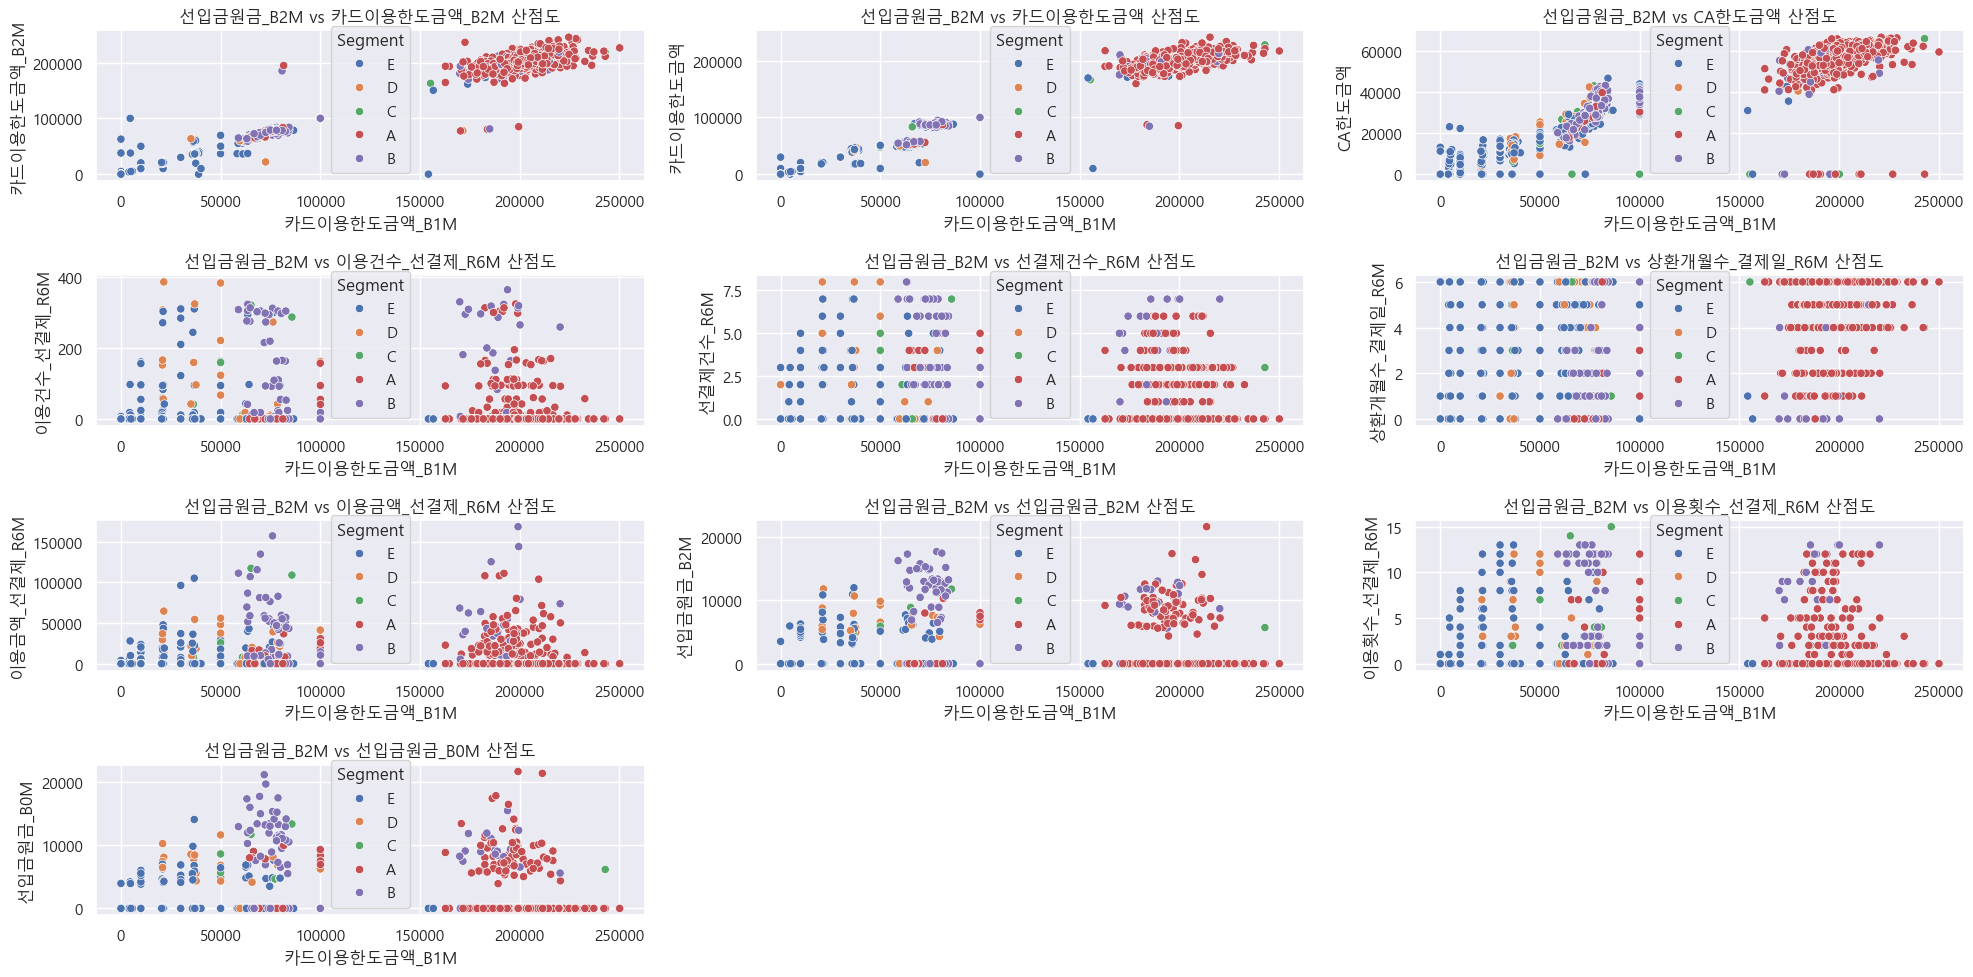

<Figure size 1200x600 with 0 Axes>

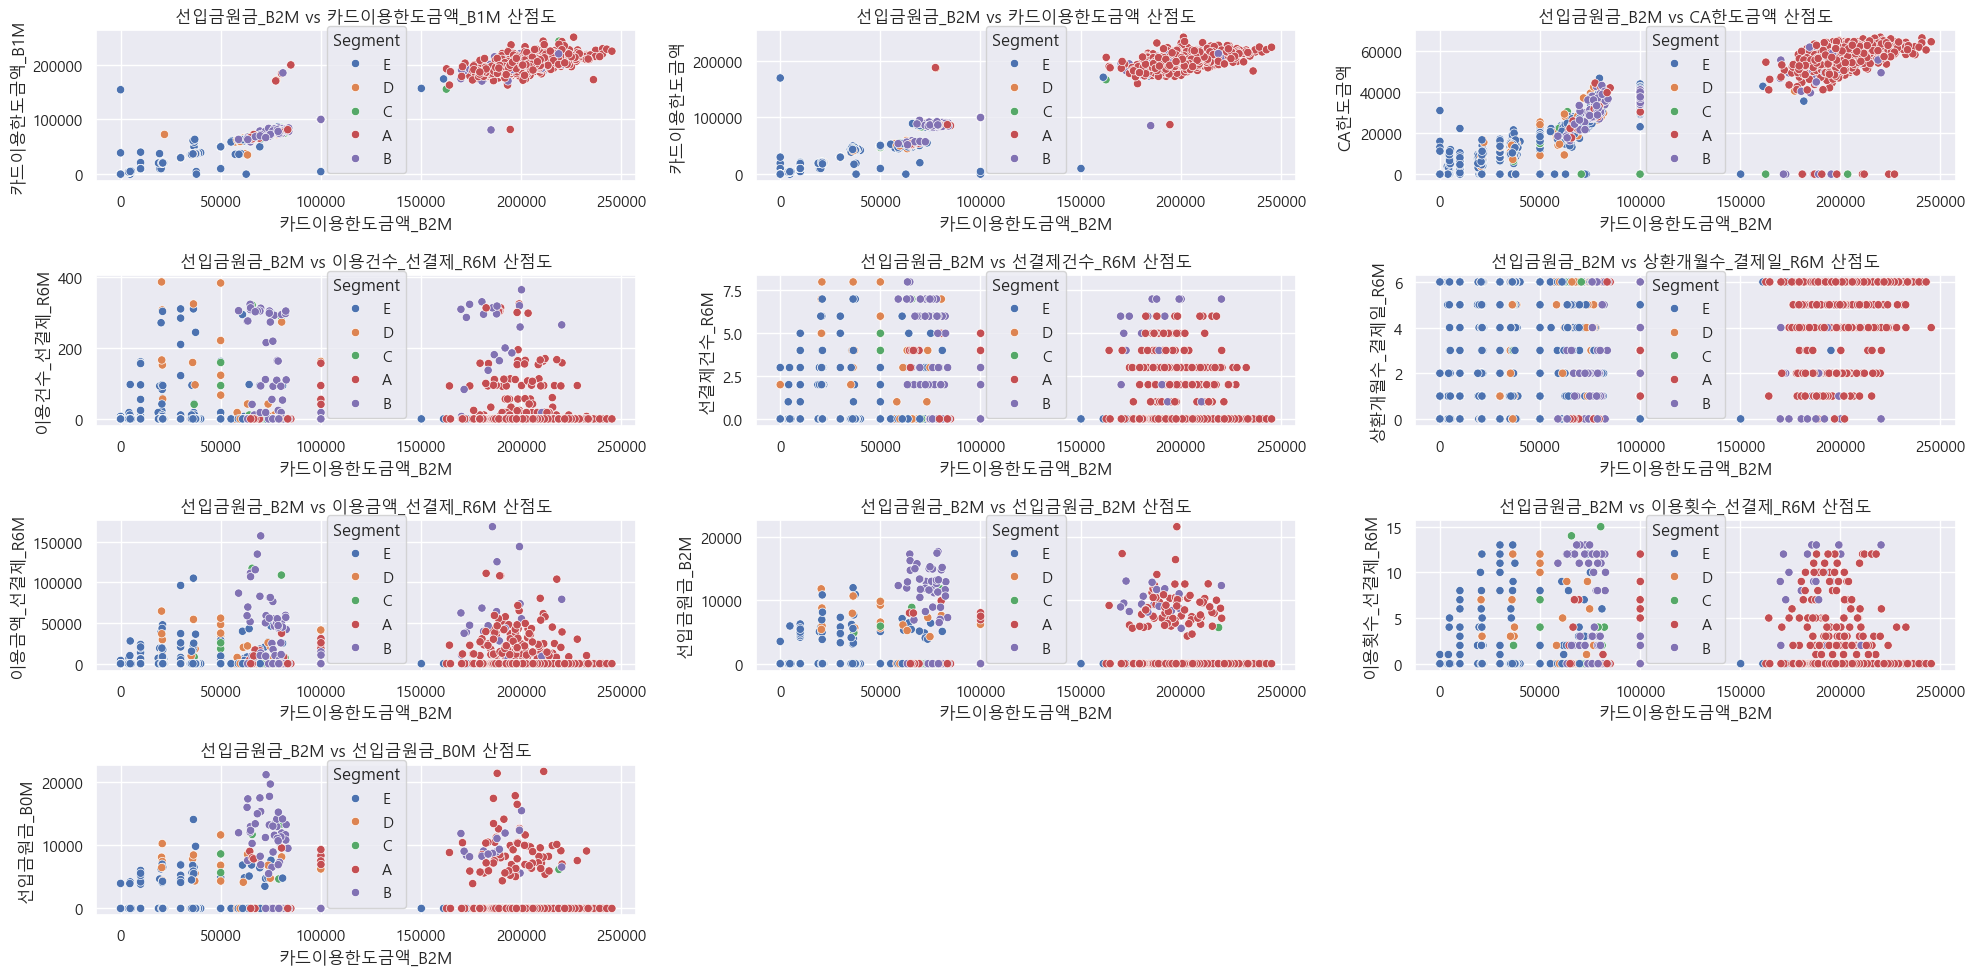

<Figure size 1200x600 with 0 Axes>

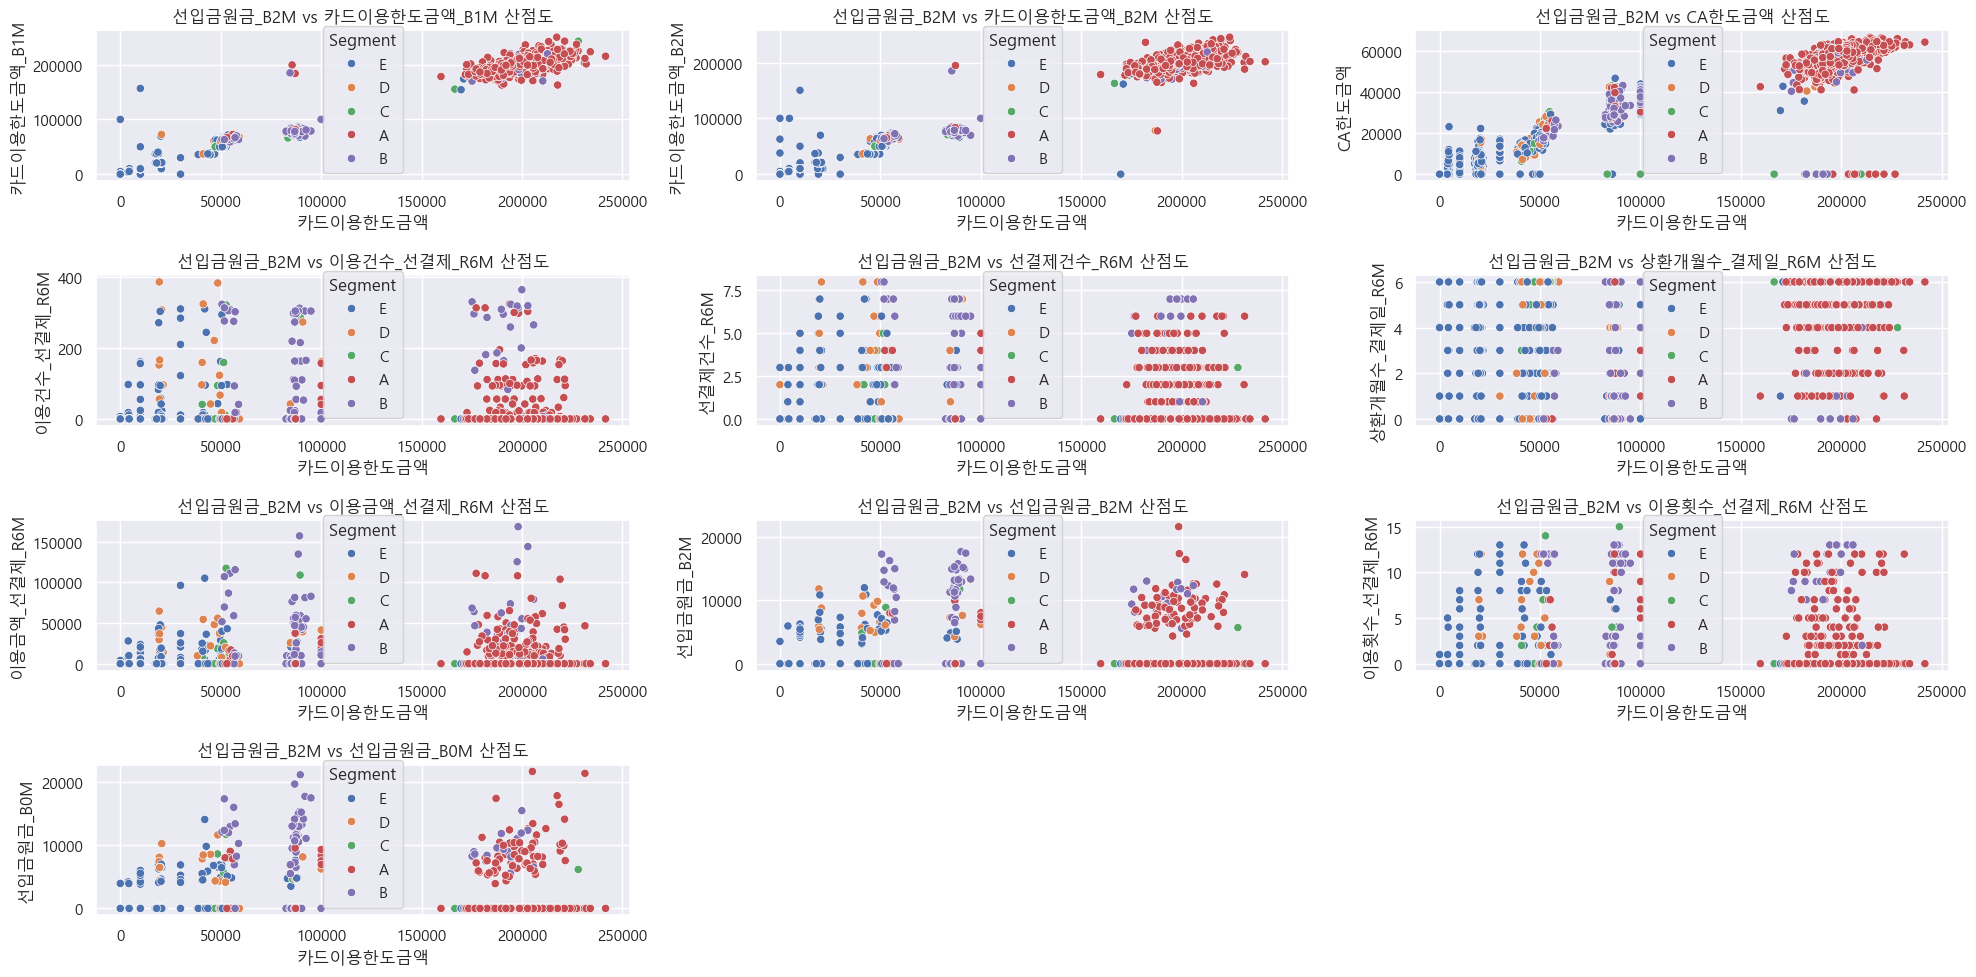

<Figure size 1200x600 with 0 Axes>

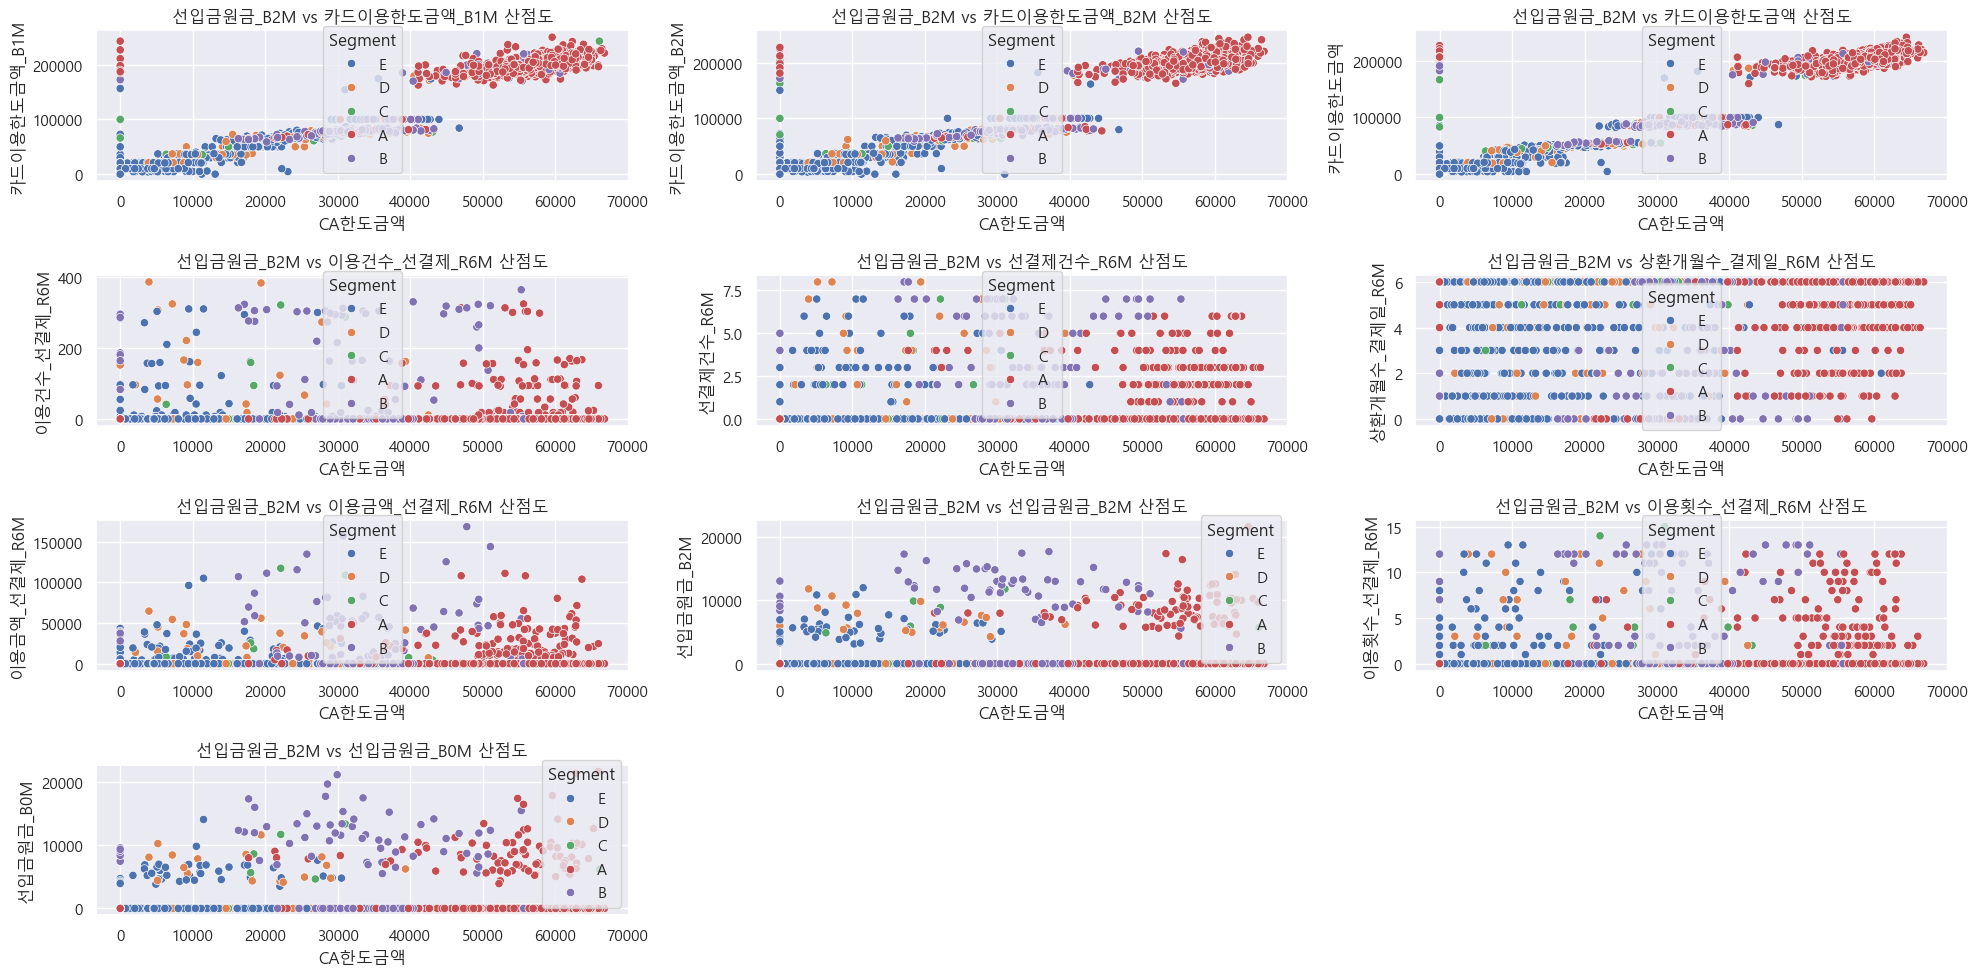

<Figure size 1200x600 with 0 Axes>

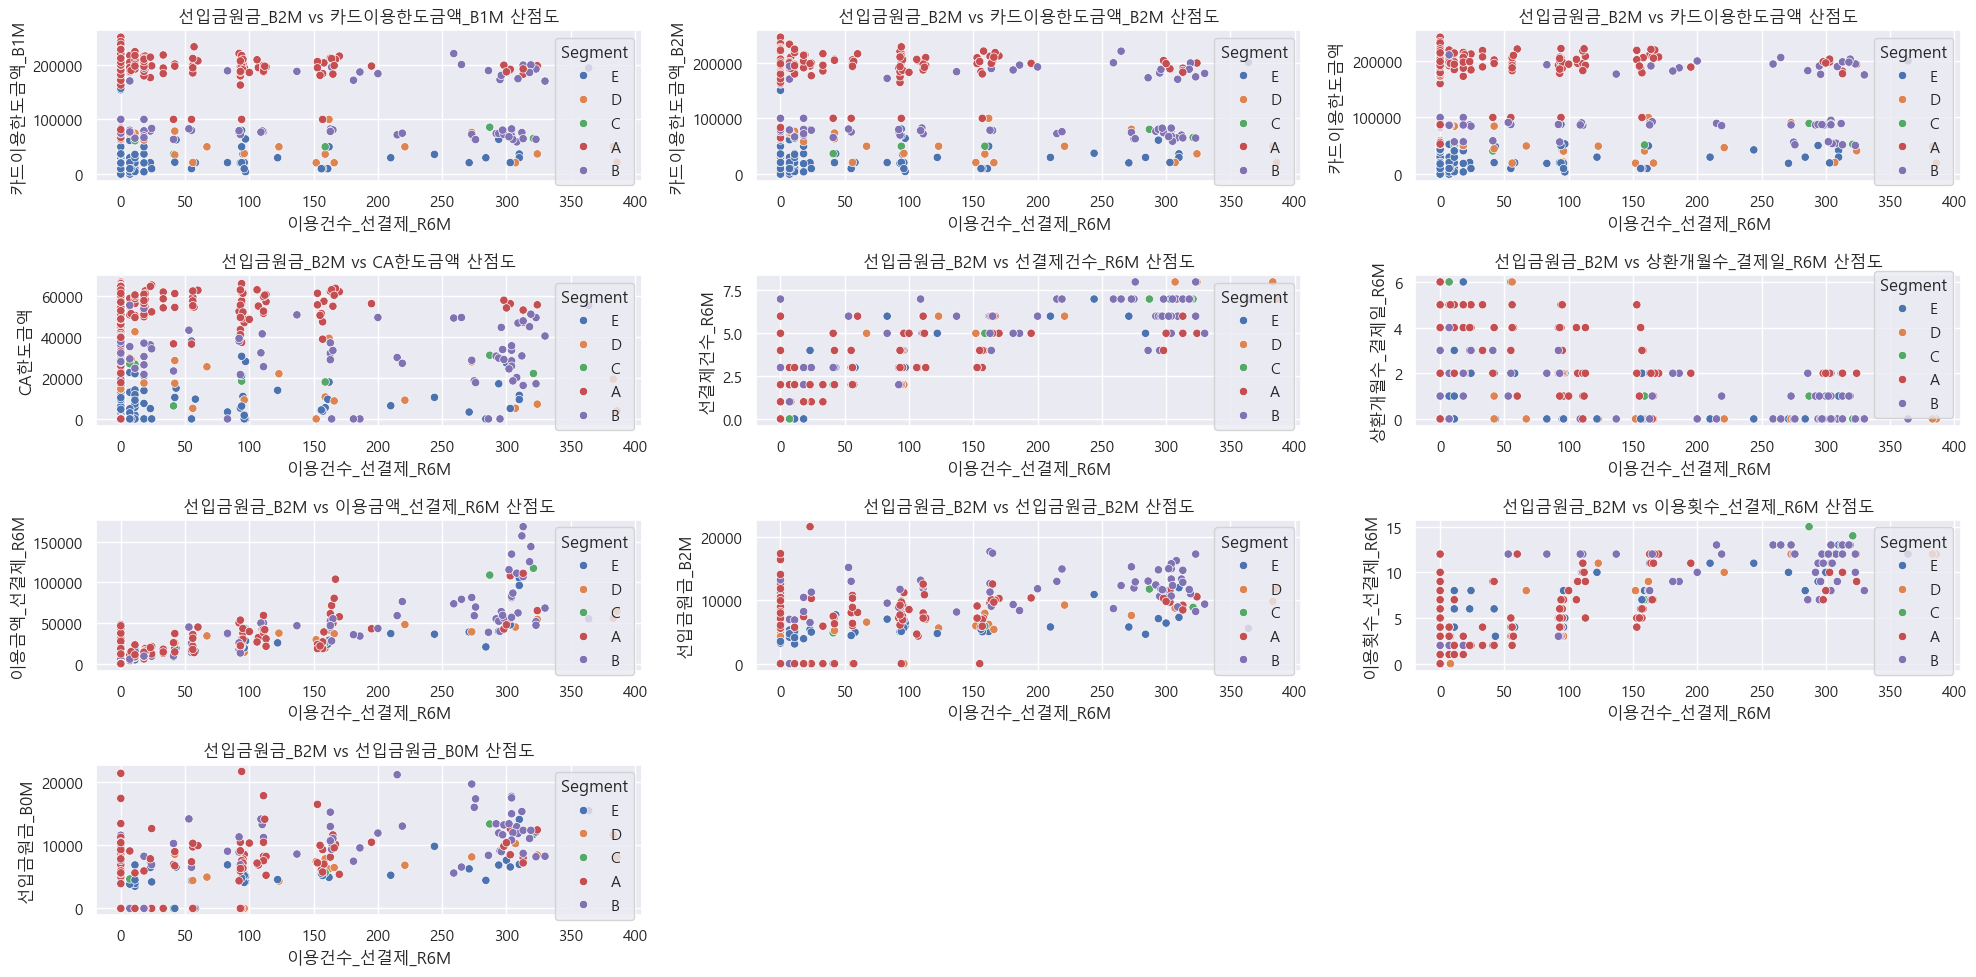

<Figure size 1200x600 with 0 Axes>

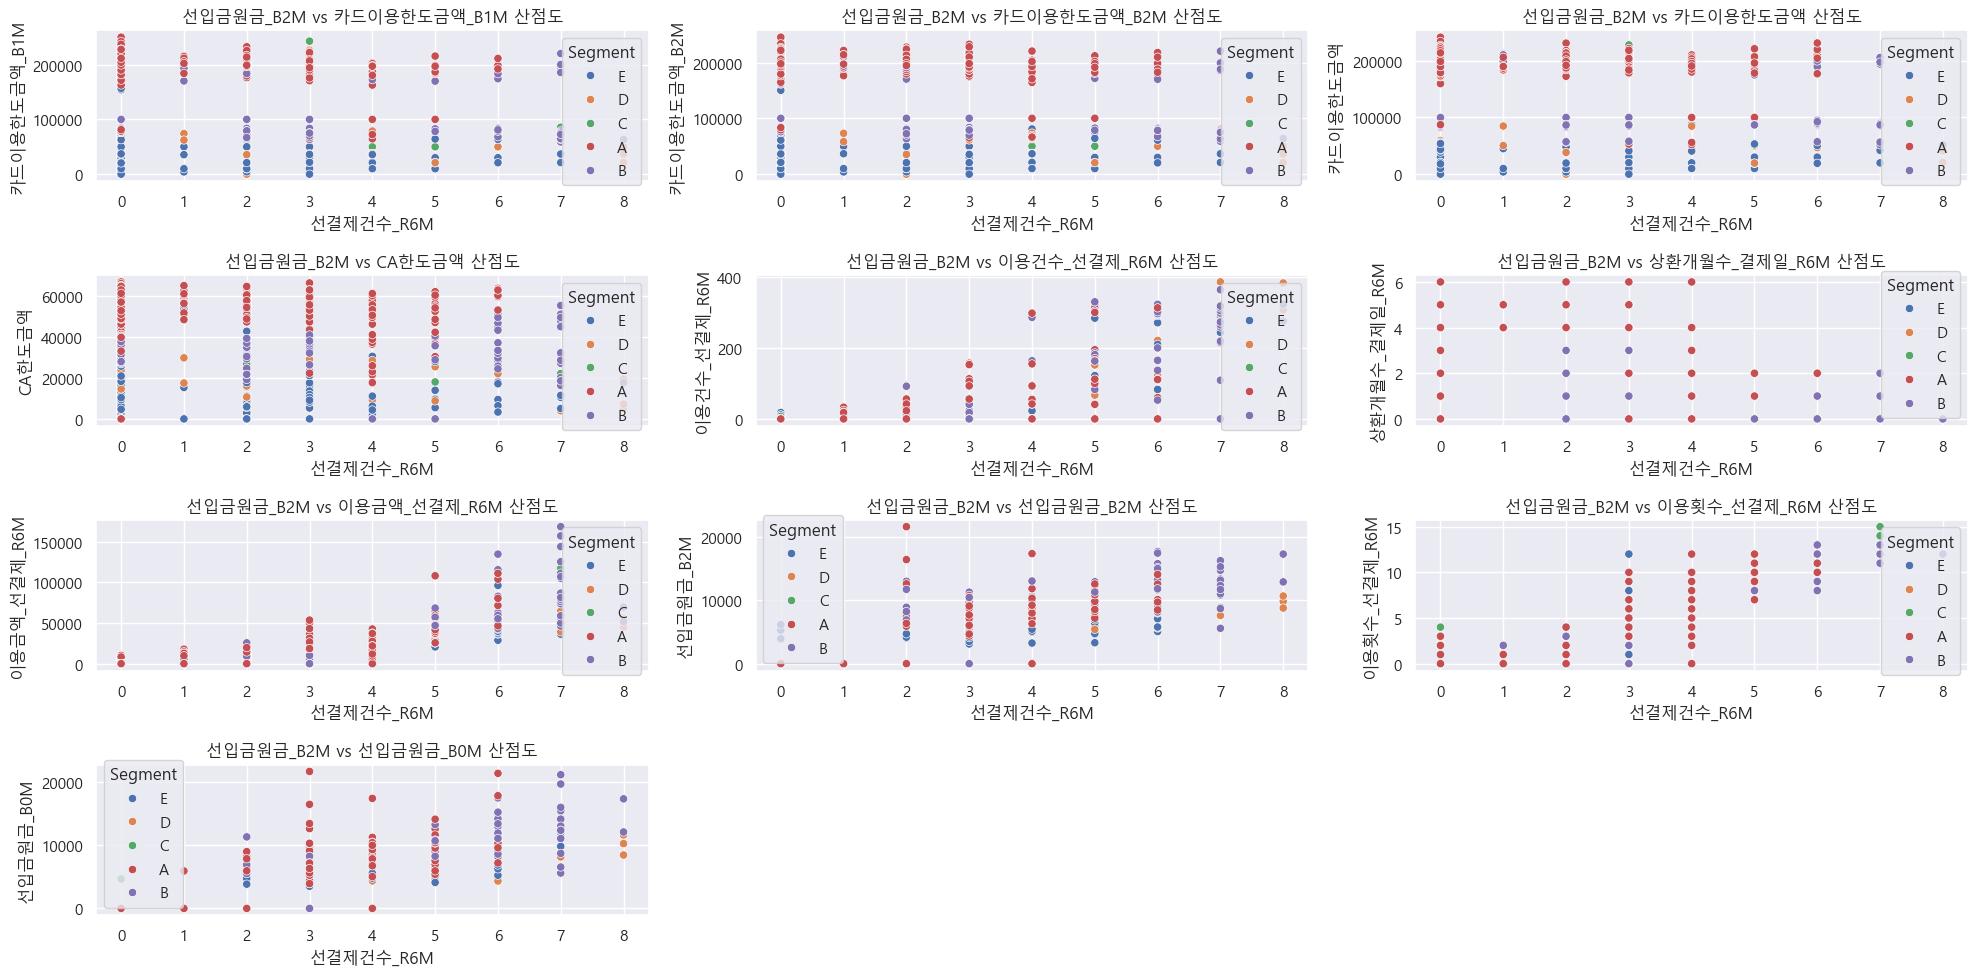

<Figure size 1200x600 with 0 Axes>

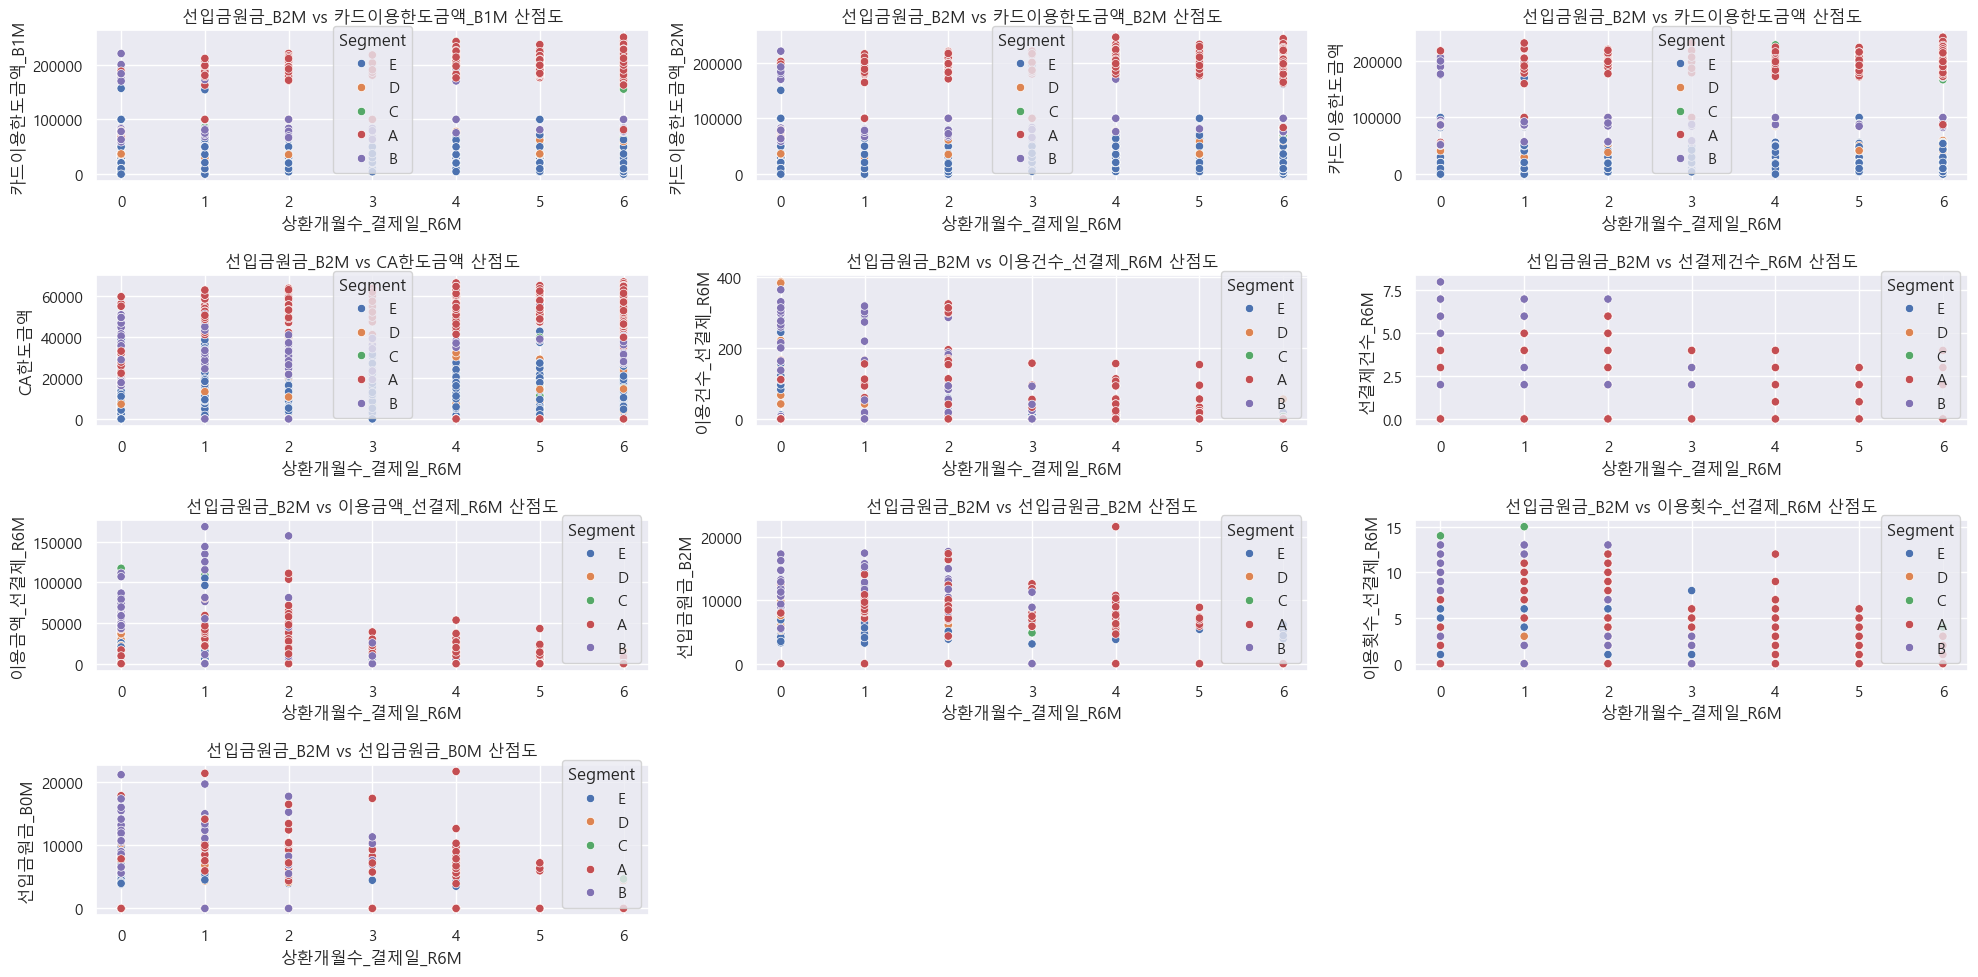

<Figure size 1200x600 with 0 Axes>

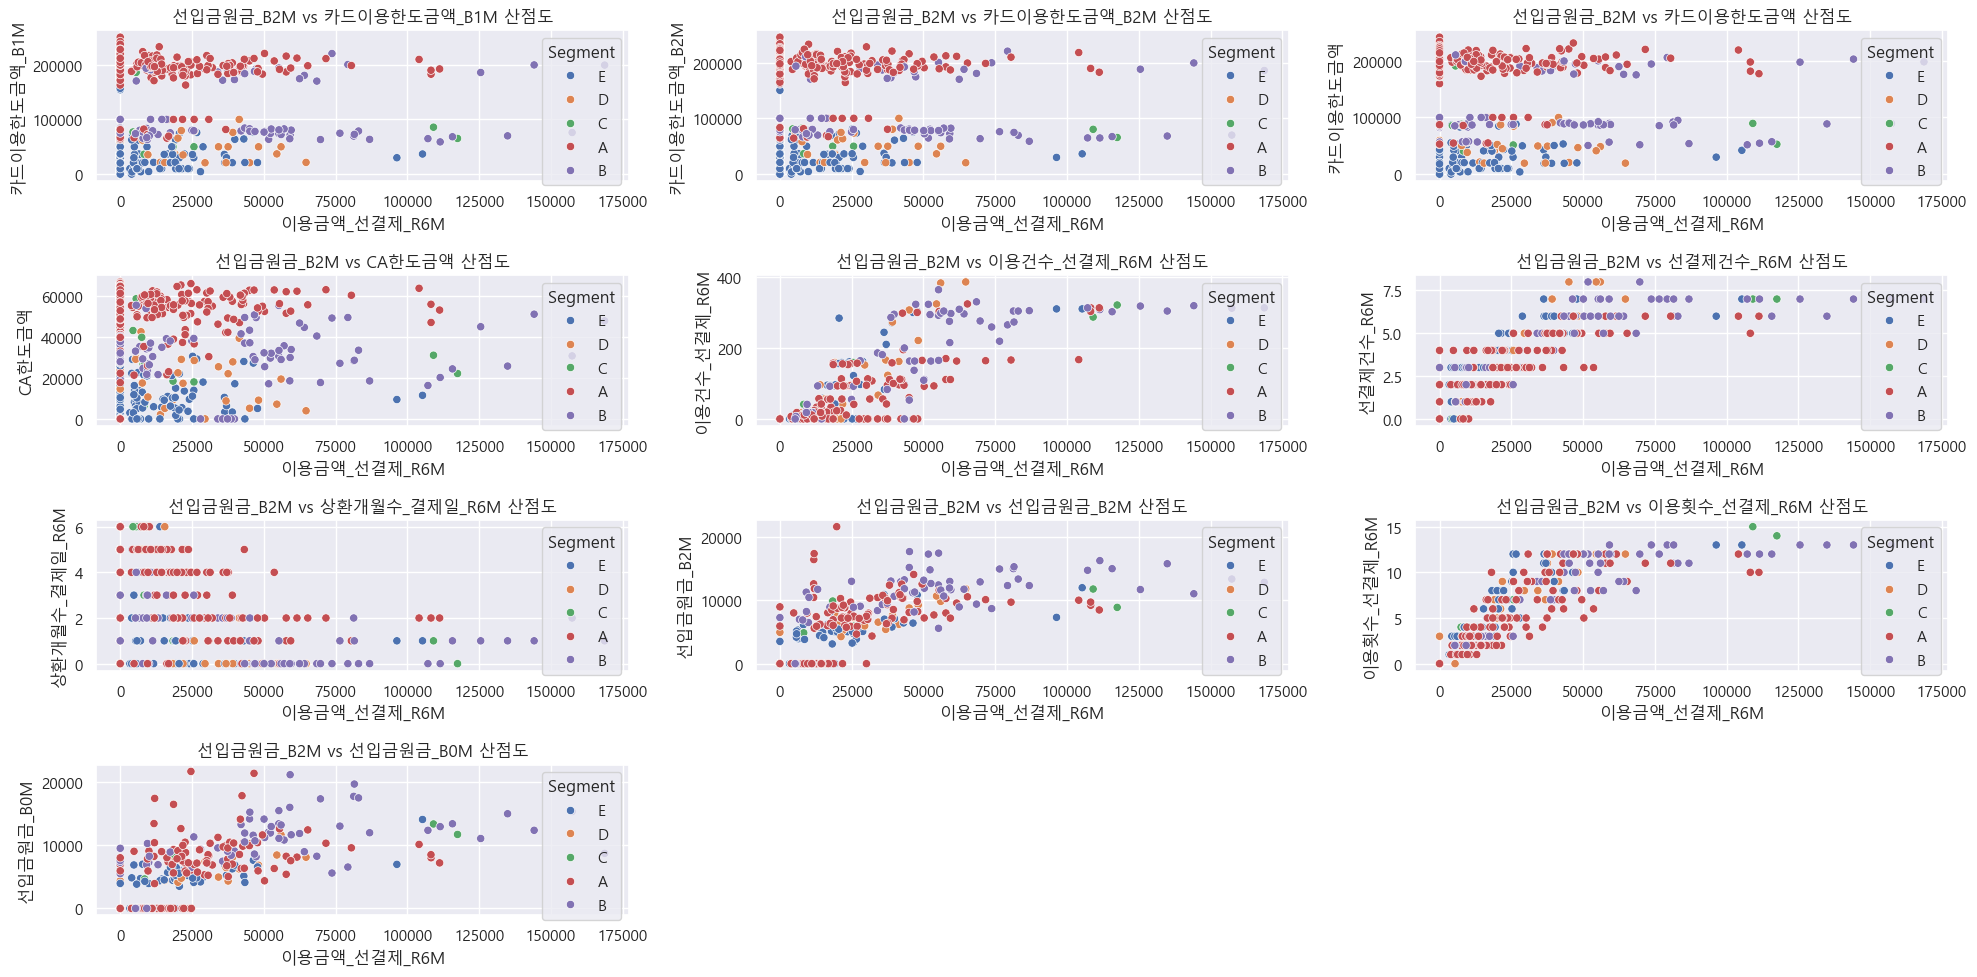

<Figure size 1200x600 with 0 Axes>

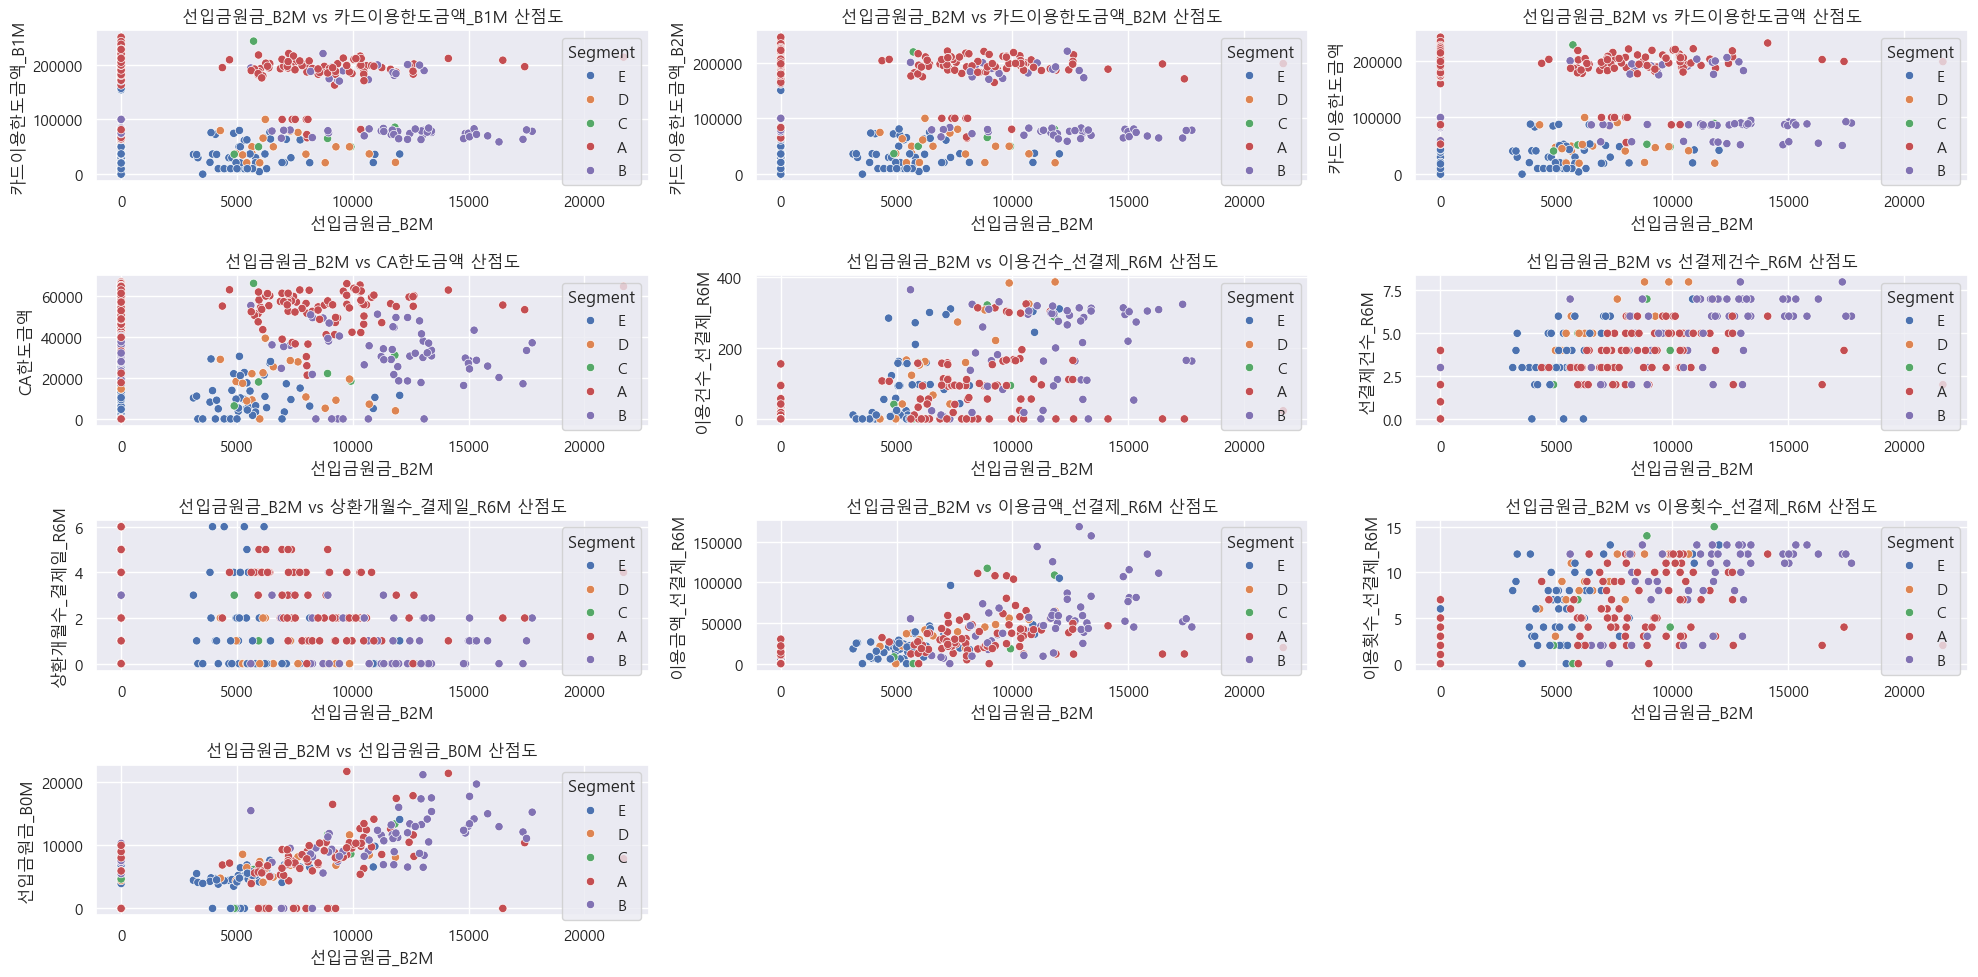

<Figure size 1200x600 with 0 Axes>

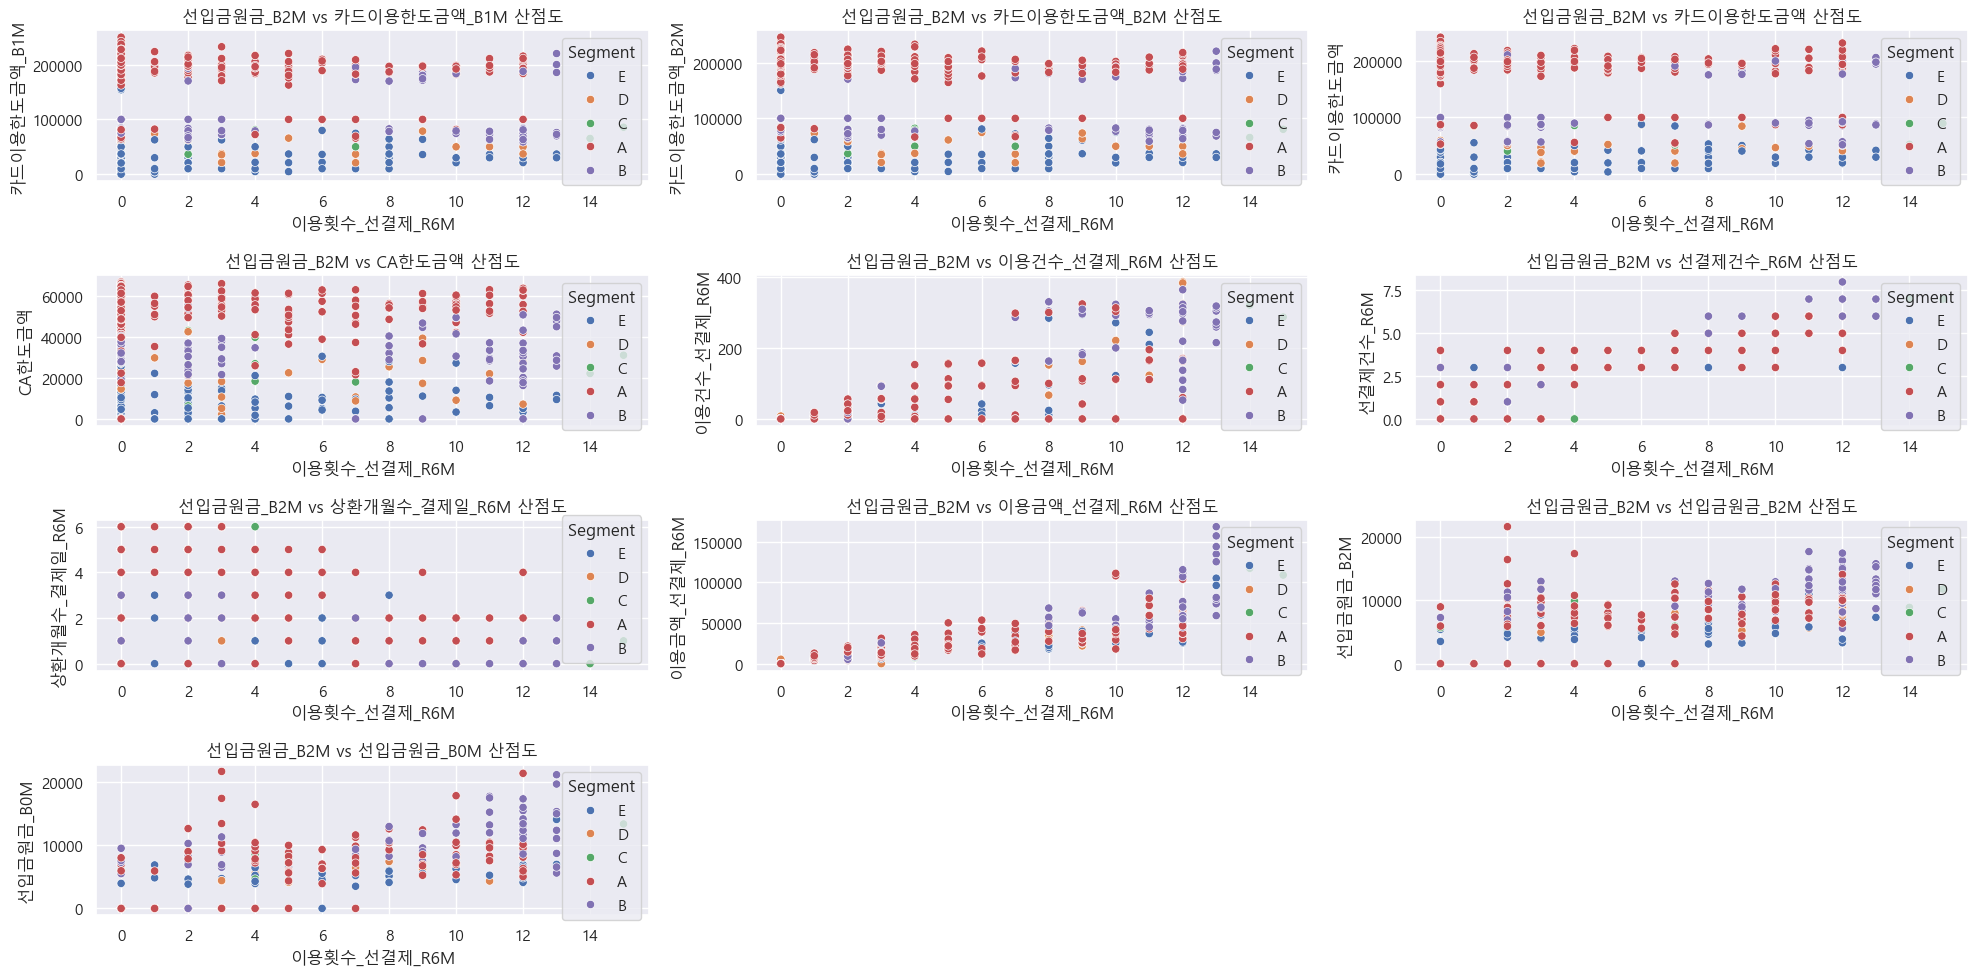

<Figure size 1200x600 with 0 Axes>

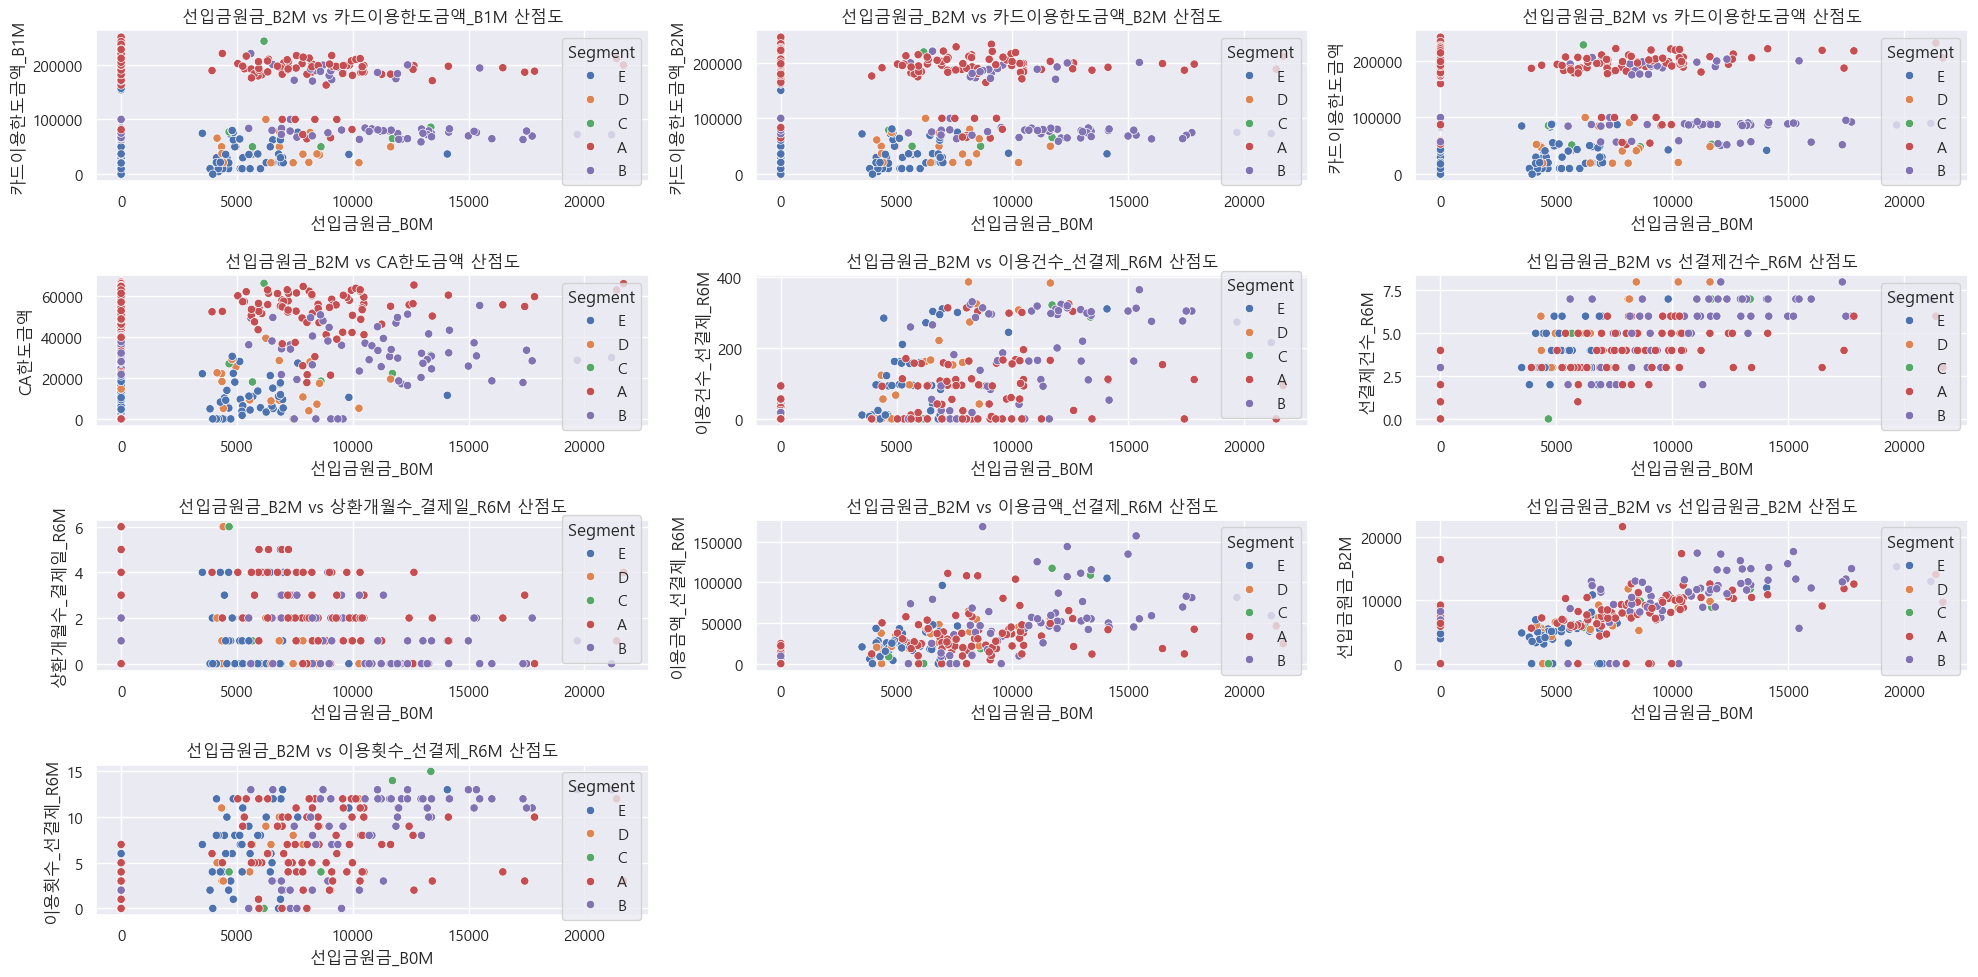

<Figure size 1200x600 with 0 Axes>

In [165]:
features =  ['카드이용한도금액_B1M'
,'카드이용한도금액_B2M'     
,'카드이용한도금액'       
,'CA한도금액'          
,'이용건수_선결제_R6M'    
,'선결제건수_R6M'        
,'상환개월수_결제일_R6M'   
,'이용금액_선결제_R6M'     
,'선입금원금_B2M'       
,'이용횟수_선결제_R6M'     
,'선입금원금_B0M'    ]

samples_per_category = 1000

stratified_sample_df = pd.DataFrame()

for category, group in df_cd.groupby('ab'):
    n_to_sample = min(len(group), samples_per_category)
    sampled_group = group.sample(n=n_to_sample, random_state=42, replace=False)
    stratified_sample_df = pd.concat([stratified_sample_df, sampled_group])

for col in features:
    plt.figure(figsize=(20, 10))
    features_1=features.copy()
    features_1.remove(col)
    for i, f in enumerate(features_1):
        plt.subplot(4, 3, i+1)
        sns.scatterplot(data=stratified_sample_df, x=col, y=f, hue='Segment')
        plt.title(f'선입금원금_B2M vs {f} 산점도')
    
    plt.subplot(4, 3, 12 ).axis('off')
    
    plt.tight_layout()
    plt.show()
    plt.clf()




samples_per_category = 1000

참고: 3개 이상의 LDA 성분은 2D 그래프로 시각화하기 어렵습니다.


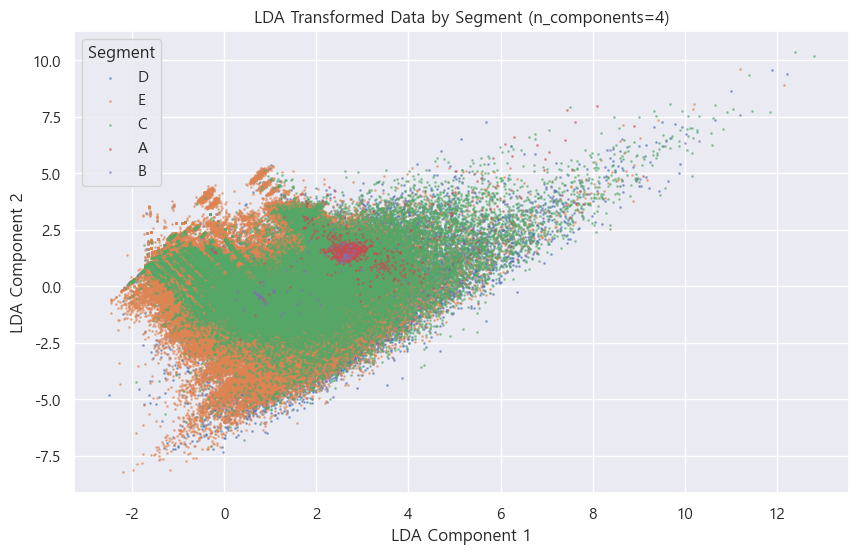

--------------------------------------------------


In [181]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



y_segment = df_cd['Segment']
X_segment = df_cd.drop(columns=['Segment', 'ab'])



# LDA 모델 설정
# LDA의 n_components는 min(피처 개수, 타겟 클래스 수 - 1) 입니다.
n_classes_segment = len(y_segment.unique())
# 현재 X_segment의 피처 개수는 X_segment.shape[1] 입니다.
n_components_segment = min(X_segment.shape[1], n_classes_segment - 1)

if n_components_segment < 1:
    print("경고: 'Segment'를 타겟으로 하는 LDA를 수행하기에 충분한 피처 또는 클래스가 없습니다.")
    print(f"  현재 피처 개수: {X_segment.shape[1]}, Segment 클래스 개수: {n_classes_segment}")
else:
    lda_segment = LinearDiscriminantAnalysis(n_components=n_components_segment)
    
    # LDA 학습 및 변환
    X_segment_lda = lda_segment.fit_transform(X_segment, y_segment)

    print(f"Segment를 타겟으로 LDA 변환 후 X_segment_lda.shape: {X_segment_lda.shape}")

# 시각화 (축소된 차원에 따라)
plt.figure(figsize=(10, 6))
if n_components_segment == 1:
    sns.histplot(x=X_segment_lda.flatten(), hue=y_segment, kde=True, palette='viridis', bins=30)
    plt.xlabel('LDA Component 1')
    plt.ylabel('Count')
elif n_components_segment == 2:
    for class_label in y_segment.unique():
        subset = X_segment_lda[y_segment == class_label]
        plt.scatter(subset[:, 0], subset[:, 1], label=class_label, alpha=0.7)
    plt.xlabel('LDA Component 1')
    plt.ylabel('LDA Component 2')
else:
    print("참고: 3개 이상의 LDA 성분은 2D 그래프로 시각화하기 어렵습니다.")
    for class_label in y_segment.unique():
        subset = X_segment_lda[y_segment == class_label]
        plt.scatter(subset[:, 0], subset[:, 1], label=class_label,s=1, alpha=0.5)
    plt.xlabel('LDA Component 1')
    plt.ylabel('LDA Component 2')
plt.title(f'LDA Transformed Data by Segment (n_components={n_components_segment})')
plt.legend(title='Segment')
plt.show()

print("-" * 50)

--- Segment를 타겟으로 하는 LDA ---

Segment를 타겟으로 하는 LDA의 컴포넌트별 컬럼 기여도 (계수):
  LDA coef_ 속성은 클래스별 판별 함수 계수를 나타냅니다. (해석 주의)
  각 열은 원본 피처, 각 행은 클래스별 계수입니다.

  **가장 큰 판별 함수 (주로 Component 1)에 대한 피처 기여도 (절댓값 기준):**
  LDA 'scalings_' (각 판별 함수가 원본 피처의 선형 결합을 나타내는 가중치):
     num__선결제건수_R6M  num__이용횟수_선결제_R6M  num__상환개월수_결제일_R6M  num__이용건수_선결제_R6M  \
LD1        0.471764           0.266359            0.159797           0.006994   
LD2        0.453484           0.474875            0.324302           0.011960   

     num__선입금원금_B0M  num__선입금원금_B2M  num__이용금액_선결제_R6M  num__CA한도금액  \
LD1        0.000141        0.000121           0.000054     0.000011   
LD2        0.000295        0.000190           0.000073     0.000037   

     num__카드이용한도금액_B2M  num__카드이용한도금액  num__카드이용한도금액_B1M  
LD1           0.000008       0.000006       3.408388e-07  
LD2           0.000005       0.000004       1.483563e-05  


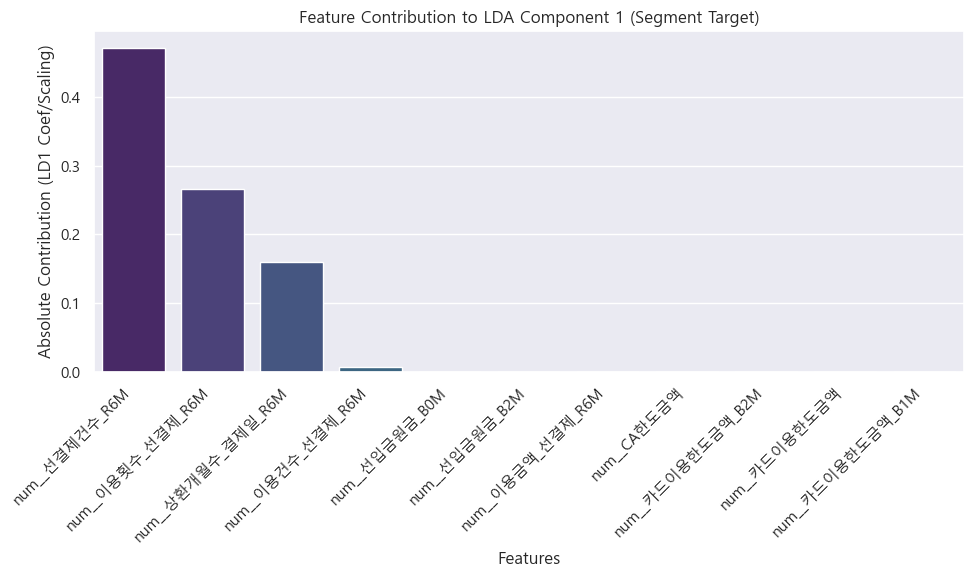

In [189]:
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns


print("--- Segment를 타겟으로 하는 LDA ---")

y_segment = df_cd['Segment']
X_segment = df_cd.drop(columns=['Segment', 'ab'])

categorical_features_segment = X_segment.select_dtypes(include='object').columns
numerical_features_segment = X_segment.select_dtypes(include=np.number).columns

preprocessor_segment = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_segment),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_segment)
    ],
    remainder='passthrough'
)

# LDA 모델 설정 (n_components를 2로 설정하여 2개의 컴포넌트 계수를 보도록 시도)
n_classes_segment = len(y_segment.unique())
n_components_segment = min(2, len(numerical_features_segment) + sum(len(X_segment[col].unique()) for col in categorical_features_segment), n_classes_segment - 1)


if n_components_segment < 1:
    print(f"경고: 'Segment'를 타겟으로 하는 LDA를 수행하기에 충분한 피처 또는 클래스가 없습니다. (n_components_segment: {n_components_segment})")
else:
    lda_pipeline_segment = Pipeline(steps=[
        ('preprocessor', preprocessor_segment),
        ('lda', LinearDiscriminantAnalysis(n_components=n_components_segment))
    ])
    
    lda_pipeline_segment.fit(X_segment, y_segment) # fit만 수행

    # 학습된 LDA 모델 객체 가져오기
    lda_model_segment = lda_pipeline_segment.named_steps['lda']

    # 전처리된 피처 이름 가져오기
    # ColumnTransformer의 get_feature_names_out()을 사용하여 전처리 후의 컬럼 이름 얻기
    feature_names_out_segment = lda_pipeline_segment.named_steps['preprocessor'].get_feature_names_out()

    print(f"\nSegment를 타겟으로 하는 LDA의 컴포넌트별 컬럼 기여도 (계수):")
    # coef_는 (n_classes, n_features) 형태이므로, 판별 함수는 (n_classes - 1)개 나옵니다.
    # 각 판별 함수에 대한 계수를 확인합니다.
    
    # LDA coef_는 각 클래스에 대한 선형 판별 함수의 계수를 반환합니다.
    # 이를 컴포넌트별 기여도로 해석하려면 조금 더 가공이 필요할 수 있습니다.
    # 일반적으로, LDA의 coef_는 '결정 경계'를 구성하는 데 사용되는 계수로 해석됩니다.
    # 각 판별 함수(컴포넌트)에 대한 기여도를 직접적으로 보기 위해서는
    # lda.scalings_ 또는 lda.coef_를 사용하지만 해석에 주의가 필요합니다.
    # 여기서는 각 원본 피처가 클래스 분리에 기여하는 정도를 나타내는
    # '결정 경계'의 계수로 해석해 보겠습니다.
    
    # n_components가 1인 경우 (이진 분류)
    if n_components_segment == 1:
        print(f"  LDA Component 1 (결정 경계):")
        for feature_name, coef_val in zip(feature_names_out_segment, lda_model_segment.coef_[0]):
            print(f"    {feature_name}: {coef_val:.4f}")
    # n_components가 2 이상인 경우
    elif n_components_segment >= 2:
        # 각 클래스에 대한 계수를 출력합니다.
        # 주의: LDA의 coef_는 PCA의 components_처럼 각 "컴포넌트의 가중치"로 직접 해석하기 어렵습니다.
        # 이는 각 클래스의 평균(centroid)과 공분산 행렬을 통해 결정 경계를 구성하는 데 사용되는 계수입니다.
        # 각 판별 함수(컴포넌트)에 대한 직접적인 기여도를 보려면 `scalings_` 속성을 더 깊게 분석해야 합니다.
        # 그러나 간단하게는 coef_의 절댓값이 큰 피처가 클래스 분리에 중요하다고 볼 수 있습니다.
        print("  LDA coef_ 속성은 클래스별 판별 함수 계수를 나타냅니다. (해석 주의)")
        print("  각 열은 원본 피처, 각 행은 클래스별 계수입니다.")
        coef_df = pd.DataFrame(lda_model_segment.coef_, columns=feature_names_out_segment)
        # 클래스 레이블이 숫자가 아니라면 매핑 필요 (현재 예시에서 y는 문자열)
        # LDA 모델의 classes_ 속성으로 클래스 순서를 알 수 있습니다.
        
        # 좀 더 직관적인 해석을 위해 각 피처의 중요도를 나타내는 `feature_importances_`와 유사한 정보를 얻는 것은
        # LDA에서는 직접적으로 제공되지 않습니다. 대신, coef_의 절댓값을 통해 간접적으로 파악할 수 있습니다.
        # 여기서는 첫 번째 판별 함수에 대한 기여도로 간략히 보여줍니다.
        if lda_model_segment.coef_.shape[0] > 0:
            print("\n  **가장 큰 판별 함수 (주로 Component 1)에 대한 피처 기여도 (절댓값 기준):**")
            # 보통 첫 번째 판별 함수 (lda.coef_[0] 또는 scalings[:, 0])의 계수를 봅니다.
            # scalings_ 속성은 클래스 개수가 n_components 보다 클 때 더 유용합니다.
            
            # `scalings_` 속성 사용 (판별 함수의 주성분 방향)
            if hasattr(lda_model_segment, 'scalings_'):
                scalings_df = pd.DataFrame(lda_model_segment.scalings_[:, :n_components_segment],
                                           index=feature_names_out_segment,
                                           columns=[f'LD{i+1}' for i in range(n_components_segment)])
                print("  LDA 'scalings_' (각 판별 함수가 원본 피처의 선형 결합을 나타내는 가중치):")
                print(scalings_df.T.abs().sort_values(by=scalings_df.columns[0], axis=1, ascending=False))
                
                # 시각화를 위해 첫 번째 컴포넌트에 대한 기여도를 바 플롯으로 그릴 수 있습니다.
                plt.figure(figsize=(10, 6))
                scalings_df['LD1_Abs'] = scalings_df['LD1'].abs()
                scalings_df_sorted = scalings_df.sort_values(by='LD1_Abs', ascending=False)
                sns.barplot(x=scalings_df_sorted.index, y=scalings_df_sorted['LD1_Abs'], palette='viridis')
                plt.title('Feature Contribution to LDA Component 1 (Segment Target)')
                plt.xlabel('Features')
                plt.ylabel('Absolute Contribution (LD1 Coef/Scaling)')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()
